In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
import kagglehub
import warnings
import keras
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import VGG16

warnings.filterwarnings("ignore")


In [3]:
'''Training adathalmaz betöltése'''
path = kagglehub.dataset_download("vuppalaadithyasairam/bone-fracture-detection-using-xrays")
train_dir = os.path.join(path, 'archive (6)/train')
print("Path to dataset files:", train_dir)

100%|██████████| 172M/172M [00:04<00:00, 38.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vuppalaadithyasairam/bone-fracture-detection-using-xrays/versions/1/archive (6)/train


In [4]:
'''Teszt adathalmaz betöltése'''
path = kagglehub.dataset_download("vuppalaadithyasairam/bone-fracture-detection-using-xrays")
test_dir = os.path.join(path, 'archive (6)/val')
print(test_dir)

/root/.cache/kagglehub/datasets/vuppalaadithyasairam/bone-fracture-detection-using-xrays/versions/1/archive (6)/val


In [5]:
'''Other címkés adathalmaz betöltése'''
path = kagglehub.dataset_download("prasunroy/natural-images")

other_dir = os.path.join(path, 'natural_images')
print(other_dir)

100%|██████████| 342M/342M [00:09<00:00, 38.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/prasunroy/natural-images/versions/1/natural_images


In [6]:
'''Tumor címkés adatok training képeinek és címkéinek begyűjtése'''
images = []
labels = []
for subfolder in os.listdir(train_dir):
    subfolder_path = os.path.join(train_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    for image_filename in os.listdir(subfolder_path):
        if image_filename.endswith(".jpg"):
            image_path = os.path.join(subfolder_path, image_filename)
            images.append(image_path)
            labels.append(subfolder)
train_df = pd.DataFrame({'image': images, 'label': labels})
train_df

,image,label
0,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
1,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
2,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
3,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
4,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
...,...,...
8858,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
8859,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
8860,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
8861,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured


In [7]:
'''Tumor címkés adatok teszt képeinek és címkéinek begyűjtése'''
images = []
labels = []
for subfolder in os.listdir(test_dir):
    subfolder_path = os.path.join(test_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    for image_filename in os.listdir(subfolder_path):
        if image_filename.endswith(".jpg"):
            image_path = os.path.join(subfolder_path, image_filename)
            images.append(image_path)
            labels.append(subfolder)
test_df = pd.DataFrame({'image': images, 'label': labels})
test_df

,image,label
0,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
1,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
2,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
3,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
4,/root/.cache/kagglehub/datasets/vuppalaadithya...,fractured
...,...,...
595,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
596,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
597,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured
598,/root/.cache/kagglehub/datasets/vuppalaadithya...,not fractured


In [8]:
'''Other címkés adatok képeinek és címkéinek begyűjtése és grayscale-elése'''
input_dir = other_dir
output_dir = "/kaggle/working/greyscale_other"
os.makedirs(output_dir, exist_ok=True)

images = []
labels = []

for subfolder in os.listdir(input_dir):
    subfolder_path = os.path.join(input_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    output_subfolder = os.path.join(output_dir, subfolder)
    os.makedirs(output_subfolder, exist_ok=True)

    for image_filename in tqdm(os.listdir(subfolder_path), desc=f"Processing {subfolder}"):
        if image_filename.endswith(".jpg"):
            src = os.path.join(subfolder_path, image_filename)
            dst = os.path.join(output_subfolder, image_filename)
            try:
                img = Image.open(src).convert("L")
                img.save(dst)
                images.append(dst)
                labels.append("other")
            except Exception as e:
                print(f"Error processing {src}: {e}")
other_df = pd.DataFrame({'image': images, 'label': labels})

Processing dog: 100%|██████████| 702/702 [00:01<00:00, 519.32it/s]


In [9]:
'''Tumor és other adathalmazok konkatenálása és keverése'''
other_train_df = other_df.sample(n=700, random_state=42)
other_test_df = other_df.drop(other_train_df.index).sample(n=300, random_state=42)

train_df = pd.concat([train_df, other_train_df], ignore_index=True)
test_df = pd.concat([test_df, other_test_df], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = train_df.sample(frac=0.5, random_state=42)

print(f"Training set: {train_df.shape}, Testing set: {test_df.shape}")

Training set: (4782, 2), Testing set: (900, 2)


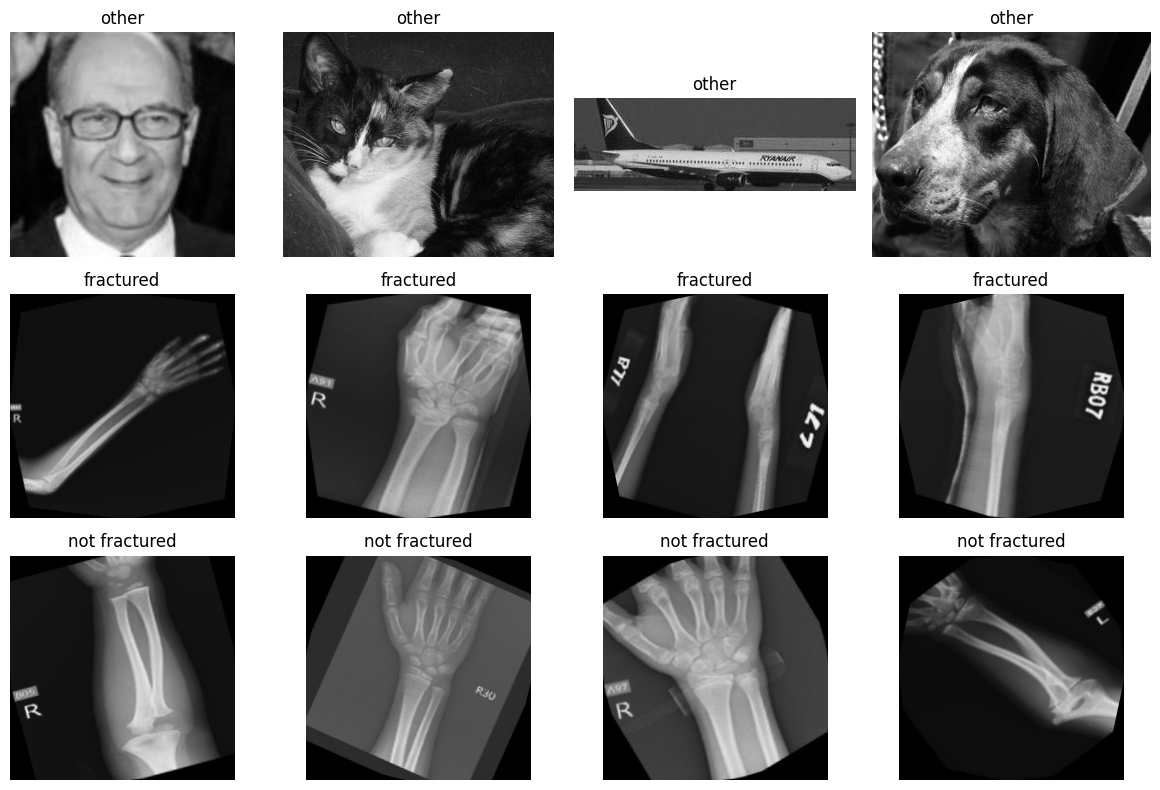

In [10]:
'''Példa képek kirajzolása'''
def plot_class_samples(df, classes, num_samples=4):
    plt.figure(figsize=(12, 8))

    for i, cls in enumerate(classes):
        class_images = df[df['label'] == cls]['image'].sample(num_samples, random_state=42)

        for j, img_path in enumerate(class_images):
            img = Image.open(img_path)
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(cls)

    plt.tight_layout()
    plt.show()

classes = train_df['label'].unique()

plot_class_samples(train_df, classes)

In [11]:
'''Címkék sorrendjének meghatározása'''
true_labels = sorted(test_df['label'].unique())
print(true_labels)

['fractured', 'not fractured', 'other']


Text(0.5, 1.0, 'Train labels count')

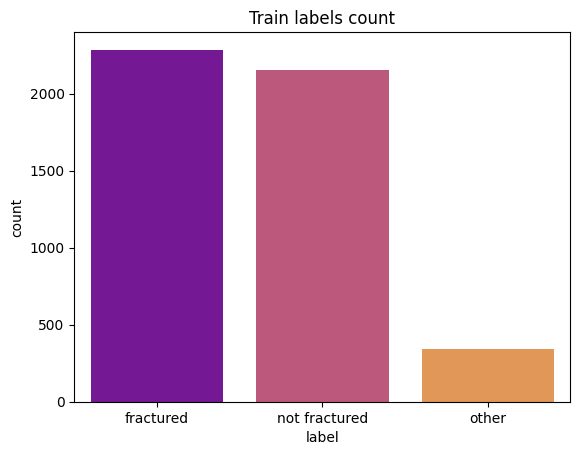

In [12]:
'''Training adatok mennyisége'''
sns.countplot(data=train_df,x='label',palette='plasma',order=true_labels)
plt.title('Train labels count')

Text(0.5, 1.0, 'Test labels count')

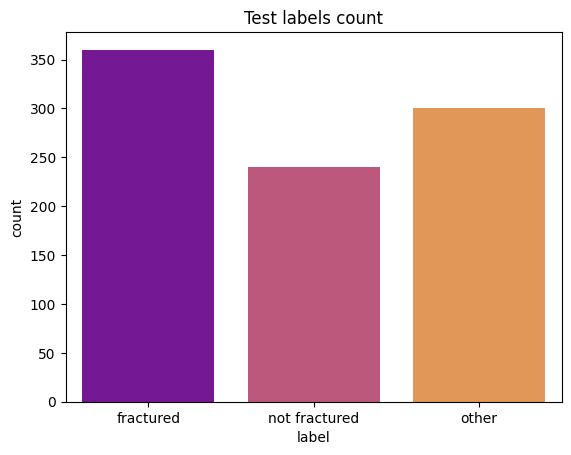

In [13]:
'''Teszt adatok mennyisége'''
sns.countplot(data=test_df,x='label',palette='plasma',order=true_labels)
plt.title('Test labels count')

In [14]:
'''Training és validációs halmaz elválasztása'''
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [15]:
'''Generátorok előállítása'''
def create_data_generators(train, test, val):
    image_size = (224, 224)
    batch_size = 32
    datagen = ImageDataGenerator(rescale=1./255)

    train_generator = datagen.flow_from_dataframe(
        train,
        x_col='image',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

    test_generator = datagen.flow_from_dataframe(
        test,
        x_col='image',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    val_generator = datagen.flow_from_dataframe(
        val,
        x_col='image',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

    return train_generator, test_generator, val_generator

In [16]:
train_generator , test_generator, val_generator = create_data_generators(train_df, test_df, valid_df)

Found 3825 validated image filenames belonging to 3 classes.
Found 900 validated image filenames belonging to 3 classes.
Found 957 validated image filenames belonging to 3 classes.


In [17]:
print(train_generator.class_indices)

{'fractured': 0, 'not fractured': 1, 'other': 2}


In [18]:
'''Model meghatározása'''
base_model = keras.applications.VGG16(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,408,899 (154.15 MB)

 Trainable params: 25,694,211 (98.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

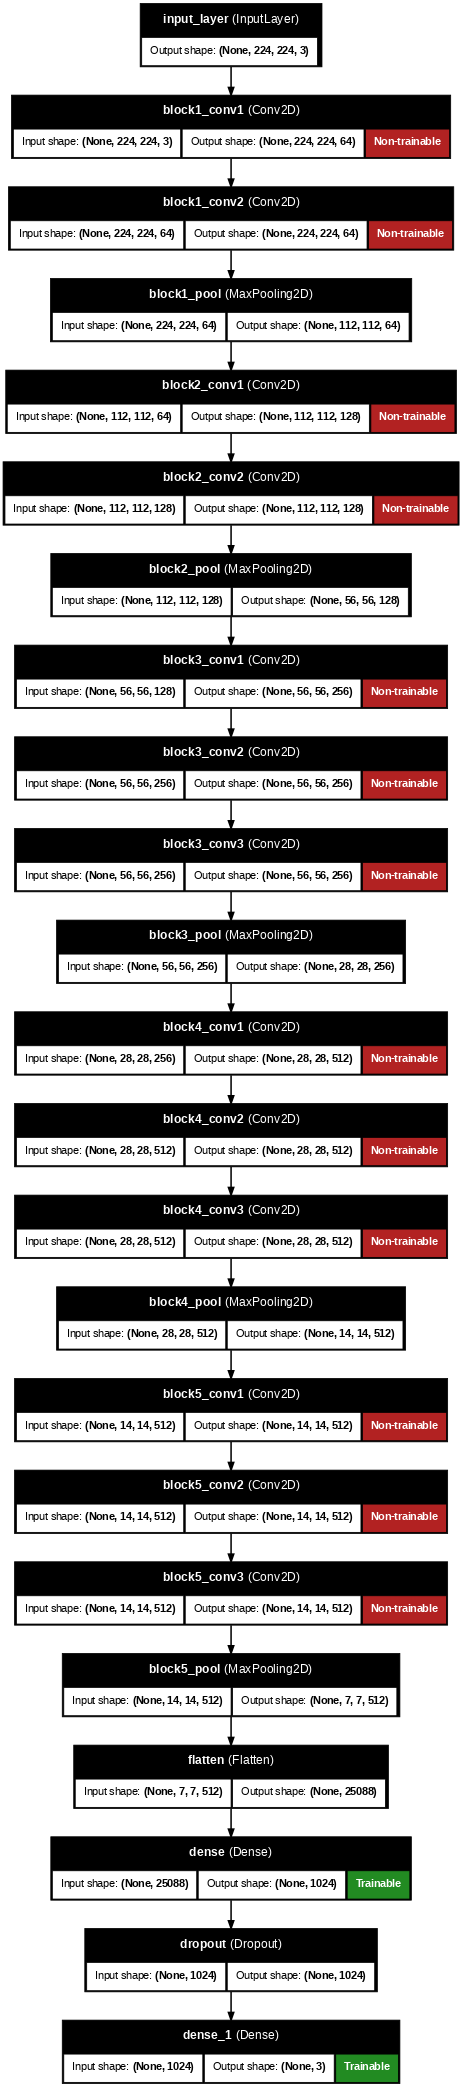

In [19]:
plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=55,
    show_layer_activations=False,
    show_trainable=True
)

In [20]:
'''Model tanítása'''
hist = model.fit(train_generator, epochs=8, validation_data=val_generator)

Epoch 1/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2959s 25s/step - accuracy: 0.6204 - loss: 3.1524 - val_accuracy: 0.8882 - val_loss: 0.2801
Epoch 2/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2946s 25s/step - accuracy: 0.8920 - loss: 0.2707 - val_accuracy: 0.8913 - val_loss: 0.2304
Epoch 3/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2930s 24s/step - accuracy: 0.9035 - loss: 0.2430 - val_accuracy: 0.9279 - val_loss: 0.1847
Epoch 4/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2914s 24s/step - accuracy: 0.9573 - loss: 0.1219 - val_accuracy: 0.9655 - val_loss: 0.0920
Epoch 5/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2920s 24s/step - accuracy: 0.9706 - loss: 0.0827 - val_accuracy: 0.9875 - val_loss: 0.0540
Epoch 6/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2925s 24s/step - accuracy: 0.9837 - loss: 0.0610 - val_accuracy: 0.9864 - val_loss: 0.0382
Epoch 7/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2933s 24s/step - accuracy: 0.9849 - loss: 0.0468 - val_accuracy: 0.9833 - val_loss: 0.0472
Epoch 8/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 2933s 24s/step - accuracy: 0.9825 - loss: 0.0616 - 

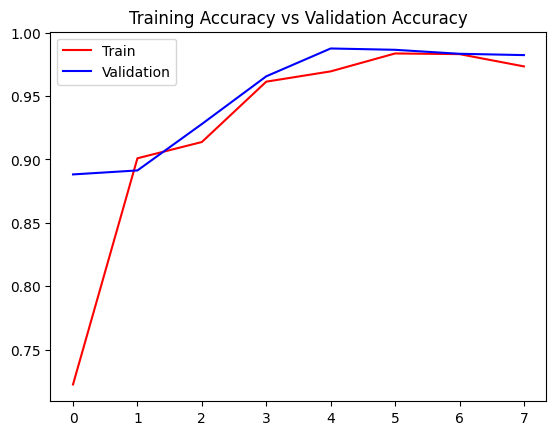

In [21]:
'''Model pontosságának kirajzolása'''
plt.title('Training Accuracy vs Validation Accuracy')

plt.plot(hist.history['accuracy'], color='red',label='Train')
plt.plot(hist.history['val_accuracy'], color='blue',label='Validation')

plt.legend()

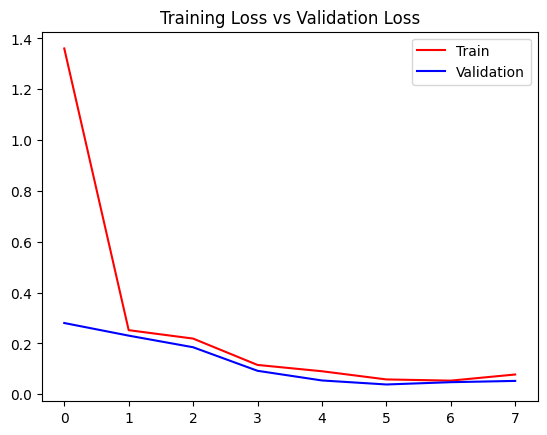

In [22]:
'''Model költségének kirajzolása'''
plt.title('Training Loss vs Validation Loss')

plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Validation')

plt.legend()

In [23]:
'''Predikciós statisztikák'''
pred=model.predict(test_generator)
predictions=np.argmax(pred,axis=1)
print(classification_report(test_generator.classes,predictions))

29/29 ━━━━━━━━━━━━━━━━━━━━ 542s 19s/step
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       360
           1       0.57      0.69      0.62       240
           2       1.00      0.98      0.99       300

    accuracy                           0.77       900
   macro avg       0.77      0.78      0.77       900
weighted avg       0.79      0.77      0.78       900



In [24]:
'''Model kiértékelése'''
model.evaluate(test_generator)

29/29 ━━━━━━━━━━━━━━━━━━━━ 543s 19s/step - accuracy: 0.7581 - loss: 0.8633


[0.7815200686454773, 0.7744444608688354]

In [25]:
'''Model mentése'''
model.save('fracture.h5')

In [26]:
'''Model letöltése'''
from google.colab import files
files.download("fracture.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

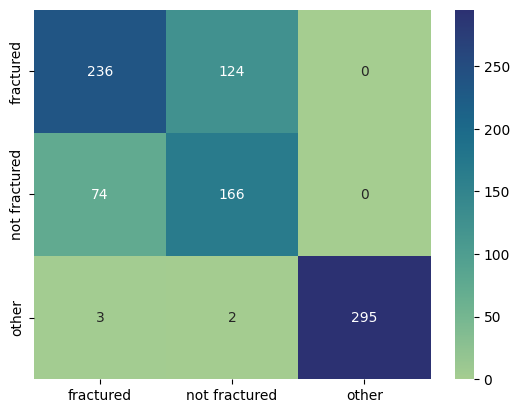

In [27]:
'''Konfúziós mátrix kirajzolása'''
conf_matrix = confusion_matrix(test_generator.classes, predictions)
labels = list(train_df['label'].unique())
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='crest', xticklabels=true_labels, yticklabels=true_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step


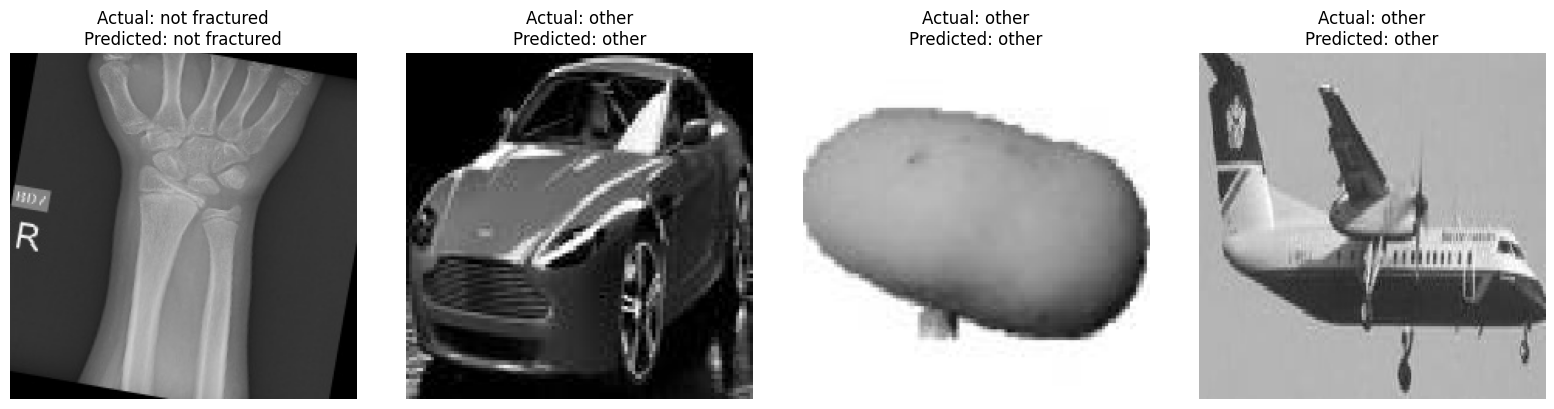

In [28]:
'''Random képeken való kiértékelés'''
import random
random_indices = random.sample(range(len(test_df)), 4)
random_paths = test_df.iloc[random_indices]['image'].values
actual_labels = test_df.iloc[random_indices]['label'].values

plt.figure(figsize=(16, 4))

for i, img_path in enumerate(random_paths):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    pred = model.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Actual: {actual_labels[i]}\nPredicted: {predicted_label}')

plt.tight_layout()
plt.show()